# How to train your own word vector embeddings using Gensim

Many tasks require embeddings or domain-specific vocabulary that pre-trained models based on a generic corpus may not represent well or at all. Standard word2vec models are not able to assign vectors to out-of-vocabulary words and instead use a default vector that reduces their predictive value.

E.g., when working with industry-specific documents, the vocabulary or its usage may change over time as new technologies or products emerge. As a result, the embeddings need to evolve as well. In addition, corporate earnings releases use nuanced language not fully reflected in Glove vectors pre-trained on Wikipedia articles.

In this notebook we illustrate the more performant gensim adaptation of the code provided by the word2vec authors. 

To illustrate the word2vec network architecture, we use the Financial News data that we first introduced in chapter 14 on Topic Modeling. 

## Imports

In [94]:
%matplotlib inline 
import warnings
from time import time
from collections import Counter
from pathlib import Path
import pandas as pd
import numpy as np
from numpy.linalg import norm
from scipy.spatial.distance import cdist, cosine

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from gensim.models import Word2Vec, KeyedVectors
from gensim.models.word2vec import LineSentence
from sklearn.decomposition import IncrementalPCA

### Settings

In [2]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('float_format', '{:,.2f}'.format)
np.random.seed(42)

### Paths

In [12]:
news_path = Path('results', 'financial_news')
analogy_path = Path('data', 'analogies-en.txt')

In [13]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f'{h:02.0f}:{m:02.0f}:{s:02.0f}'

## Model Configuration

In [14]:
gensim_path = news_path / 'gensim'
if not gensim_path.exists():
    gensim_path.mkdir(parents=True, exist_ok=True)

In [6]:
NGRAMS = 3           # Longest ngram in text
MIN_FREQ = 100
WINDOW_SIZE = 5
EMBEDDING_SIZE = 300
NEGATIVE_SAMPLES = 20
EPOCHS = 1

In [15]:
FILE_NAME = f'articles_{NGRAMS}_grams.txt'

## Sentence Generator

In [16]:
sentence_path = news_path / FILE_NAME
sentences = LineSentence(str(sentence_path))

In [ ]:
for sentence in sentences:
    print(sentence)

## Train word2vec Model

In [17]:
start = time()
model = Word2Vec(sentences, 
                 sg=1, # set to 1 for skipgram; CBOW otherwise
                 vector_size=EMBEDDING_SIZE, 
                 window=WINDOW_SIZE,
                 min_count=MIN_FREQ, 
                 negative=NEGATIVE_SAMPLES, 
                 workers=8,
                 epochs=EPOCHS, 
                 alpha=0.05)

# persist model
model.save(str(gensim_path / 'word2vec.model'))

# persist word vectors
model.wv.save(str(gensim_path / 'word_vectors.bin'))
print('Duration:', format_time(time() - start))

Duration: 00:03:35


## Evaluate results

In [18]:
cat_dict = {'capital-common-countries':'Capitals',
            'capital-world':'Capitals RoW',
            'city-in-state':'City-State',
            'currency':'Currency',
            'family':'Famliy',
            'gram1-adjective-to-adverb':'Adj-Adverb',
            'gram2-opposite':'Opposite',
            'gram3-comparative':'Comparative',
            'gram4-superlative':'Superlative',
            'gram5-present-participle':'Pres. Part.',
            'gram6-nationality-adjective':'Nationality',
            'gram7-past-tense':'Past Tense',
            'gram8-plural':'Plural',
            'gram9-plural-verbs':'Plural Verbs',
            'total':'Total'}

In [28]:
def accuracy_by_category(acc, detail=True):
    results = [[c['section'], len(c['correct']), len(c['incorrect'])] for c in acc]
    results = pd.DataFrame(results, columns=['category', 'correct', 'incorrect'])
    results['average'] = results.correct.div(results[['correct', 'incorrect']].sum(1))
    if detail:
        print(results.sort_values('average', ascending=False))
    return results.loc[results.category=='Total accuracy', ['correct', 'incorrect', 'average']].squeeze().tolist()

In [80]:
# gensim computes accuracy based on source text files
detailed_accuracy = model.wv.evaluate_word_analogies(analogy_path.as_posix(), case_insensitive=True)

KeyError: "Key 'brp' not present"

In [30]:
detailed_accuracy[0]

0.31292442497261774

In [31]:
# get accuracy per category
summary = accuracy_by_category(detailed_accuracy[1])
print('Base Accuracy: Correct {:,.0f} | Wrong {:,.0f} | Avg {:,.2%}\n'.format(*summary))

                       category  correct  incorrect  average
10  gram6-nationality-adjective      757        299     0.72
0      capital-common-countries      292        128     0.70
1                 capital-world      601        589     0.51
14               Total accuracy     2857       6273     0.31
7             gram3-comparative      282        648     0.30
4                        family       38         94     0.29
11             gram7-past-tense      342        848     0.29
8             gram4-superlative       67        239     0.22
12                 gram8-plural       56        250     0.18
13           gram9-plural-verbs       80        426     0.16
3                      currency       27        151     0.15
2                 city-in-state      214       1430     0.13
9      gram5-present-participle       71        529     0.12
5     gram1-adjective-to-adverb       24        438     0.05
6                gram2-opposite        6        204     0.03
Base Accuracy: Correct 2

In [83]:
model.wv.key_to_index = {k.lower(): v for k, v in model.wv.key_to_index.items()}

In [86]:
most_sim = model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=20)
pd.DataFrame(most_sim, columns=['token', 'similarity'])

,token,similarity
0,judy,0.42
1,howell,0.41
2,duke,0.41
3,pierce,0.41
4,cindy,0.40
5,queen_elizabeth,0.39
6,robb,0.39
7,catherine,0.39
8,jensen,0.39
9,royals,0.38


In [72]:
counter = Counter(sentence_path.read_text().split())

In [73]:
most_common = pd.DataFrame(counter.most_common(), columns=['token', 'count'])
most_common = most_common[most_common['count']> MIN_FREQ]
most_common['p'] = np.log(most_common['count'])/np.log(most_common['count']).sum()

In [87]:
similars = pd.DataFrame()
for token in np.random.choice(most_common.token, size=10, p=most_common.p):
    similars[token] = [s[0] for s in model.wv.most_similar(token)]
similars.T

,0,1,2,3,4,5,6,7,8,9
phh,ocwen,analogic,vectren,microsemi,commercehub,scana,mtge,tervita,hardinge,heico
faced,facing,face,faces,beset,despite,grappling,stiff,overcoming,mounting,stirring
stake,shareholding,stakes,edp,manipal,bought,temasek,healthscope,enel,renova,mubadala
sek_m,ebita,constant_currencies,sek,unlevered_free,ebitdas,excl,oibdan,metric_ton,ounce_aisc,keur
julius_baer,credit_agricole,scotiabank,unicredit,societe_generale,westpac,berenberg,intesa_sanpaolo,qe,ubs,commerzbank
brilliant,lifelong,stan,amazing,tonight,loves,ca_wait,wolfe,hustle,curry,mom
startups,start_ups,entrepreneurs,vc,venture,ipos,startup,companies,incubator,silicon_valley,bike_sharing
commodity,commodities,natural_gas_ngl,raw_material,derivative_contracts,commodity_derivatives,futures,natural_gas_per_mcf,per_bbl,aeco,prices
danone,reckitt_benckiser,nestle,pepsi,henkel,kering,confectionery,heineken,dr_pepper_snapple,gucci,pet_food
avoiding,deterred,avoid,savona,overheating,unresolved,stopping,flashpoint,mindful,ticking,relaxation


## Continue Training

In [88]:
accuracies = [summary]
best_accuracy = summary[-1]
for i in range(1, 10):
    start = time()
    model.train(sentences, epochs=1, total_examples=model.corpus_count)
    _, detailed_accuracy = model.wv.evaluate_word_analogies(analogy_path, case_insensitive=True)
    accuracies.append(accuracy_by_category(detailed_accuracy, detail=False))
    print(f'{i:02} | Duration: {format_time(time() - start)} | Accuracy: {accuracies[-1][-1]:.2%} ')
    if accuracies[-1][-1] > best_accuracy:
        model.save(str(gensim_path / f'word2vec_{i:02}.model'))
        model.wv.save(str(gensim_path / f'word_vectors_{i:02}.bin'))
        best_accuracy = accuracies[-1][-1]
    (pd.DataFrame(accuracies, 
                 columns=['correct', 'wrong', 'average'])
     .to_csv(gensim_path / 'accuracies.csv', index=False))
model.wv.save(str(gensim_path / 'word_vectors_final.bin'))

01 | Duration: 00:03:44 | Accuracy: 35.36% 
02 | Duration: 00:03:46 | Accuracy: 37.59% 
03 | Duration: 00:04:02 | Accuracy: 37.61% 
04 | Duration: 00:03:57 | Accuracy: 39.45% 
05 | Duration: 00:03:32 | Accuracy: 39.28% 
06 | Duration: 00:03:30 | Accuracy: 39.13% 
07 | Duration: 00:03:19 | Accuracy: 38.83% 
08 | Duration: 00:05:34 | Accuracy: 39.12% 
09 | Duration: 00:06:45 | Accuracy: 39.98% 


## Evaluate Best Model

In [1]:
pd.DataFrame(accuracies, columns=['correct', 'wrong', 'average'], index=list(range(1, len(accuracies) + 1))).average.plot()

NameError: name 'pd' is not defined

In [96]:
best_model = Word2Vec.load((gensim_path / 'word2vec_09.model').as_posix())

In [97]:
# gensim computes accuracy based on source text files
_, detailed_accuracy = best_model.wv.evaluate_word_analogies(analogy_path.as_posix(), case_insensitive=True)

In [98]:
# get accuracy per category
summary = accuracy_by_category(detailed_accuracy)
print('Base Accuracy: Correct {:,.0f} | Wrong {:,.0f} | Avg {:,.2%}\n'.format(*summary))

                       category  correct  incorrect  average
0      capital-common-countries      357         63     0.85
10  gram6-nationality-adjective      785        271     0.74
1                 capital-world      859        331     0.72
14               Total accuracy     3650       5480     0.40
4                        family       45         87     0.34
7             gram3-comparative      299        631     0.32
11             gram7-past-tense      382        808     0.32
2                 city-in-state      505       1139     0.31
12                 gram8-plural       67        239     0.22
8             gram4-superlative       66        240     0.22
9      gram5-present-participle      107        493     0.18
13           gram9-plural-verbs       87        419     0.17
3                      currency       26        152     0.15
5     gram1-adjective-to-adverb       48        414     0.10
6                gram2-opposite       17        193     0.08
Base Accuracy: Correct 3

In [101]:
results = [[c['section'], len(c['correct']), len(c['incorrect'])] for c in detailed_accuracy]
results = pd.DataFrame(results, columns=['category', 'correct', 'incorrect'])
results['category'] = results.category.map(cat_dict)
results['average'] = results.correct.div(results[['correct', 'incorrect']].sum(1))
results = results.rename(columns=str.capitalize).set_index('Category')

In [102]:
most_sim = best_model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=20)
pd.DataFrame(most_sim, columns=['token', 'similarity'])

,token,similarity
0,lewis,0.40
1,brown,0.37
2,barbara,0.36
3,bradley,0.36
4,geoffrey,0.36
5,jennifer,0.36
6,smith,0.36
7,albert,0.36
8,kelly,0.35
9,montgomery,0.35


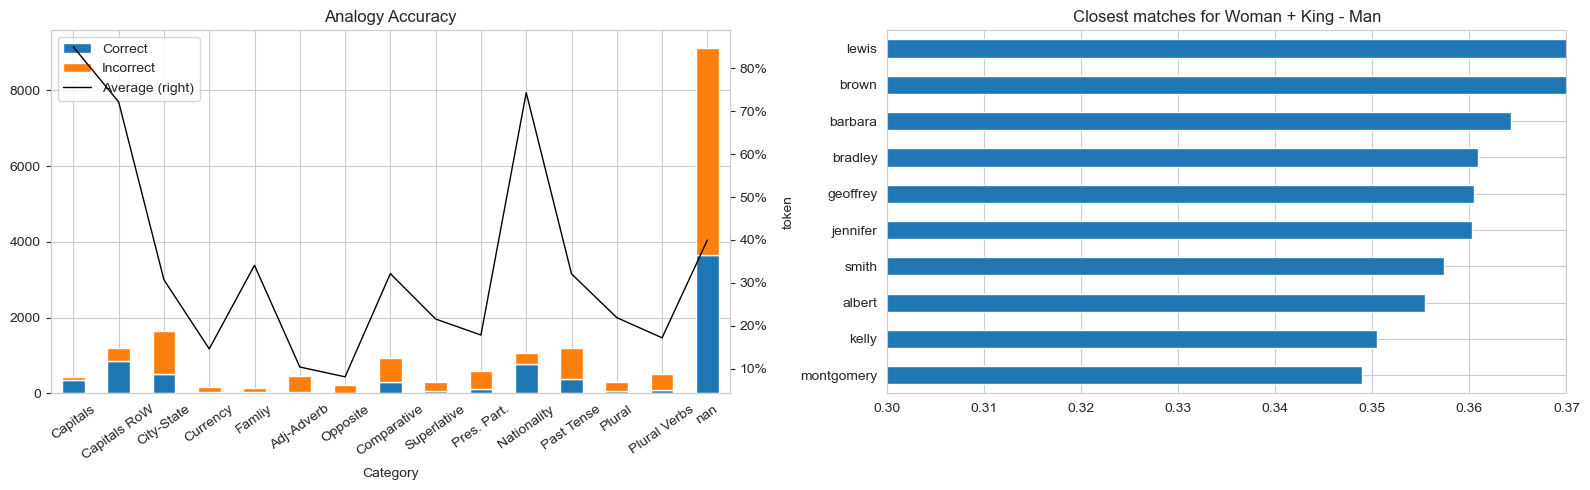

In [103]:
fig, axes = plt.subplots(figsize=(16, 5), ncols=2)

axes[0] = results.loc[:, ['Correct', 'Incorrect']].plot.bar(stacked=True, ax=axes[0]
                                                           , title='Analogy Accuracy')
ax1 = results.loc[:, ['Average']].plot(ax=axes[0], secondary_y=True, lw=1, c='k', rot=35)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

(pd.DataFrame(most_sim, columns=['token', 'similarity'])
 .set_index('token').similarity
 .sort_values().tail(10).plot.barh(xlim=(.3, .37), ax=axes[1], title='Closest matches for Woman + King - Man'))
fig.tight_layout();

In [104]:
counter = Counter(sentence_path.read_text().split())

In [105]:
most_common = pd.DataFrame(counter.most_common(), columns=['token', 'count'])
most_common = most_common[most_common['count']> MIN_FREQ]
most_common['p'] = np.log(most_common['count'])/np.log(most_common['count']).sum()

In [106]:
similars = pd.DataFrame()
for token in np.random.choice(most_common.token, size=10, p=most_common.p):
    similars[token] = [s[0] for s in best_model.wv.most_similar(token)]
similars.T

,0,1,2,3,4,5,6,7,8,9
made,undue_reliance_placed,speak_dates,events_circumstances,opinions,undertake_obligation_update,reasonable,circumstances,undertakes_obligation_update,beliefs,undertake_obligation_update_revise
echoed,comments,saying,cited,conservative,praised,stressed,lawmaker,defended,urging,slideshow_images
quality,innovative,affordable,reliability,excellent,custom,exceptional,experiences,grade,efficiency,passion
ticking,clock,hidden,borrowing,rising,italy,playing,bomb,lingering,perhaps,edged
maintains,headquartered,maintaining,employs,operates,offices,serves,maintained,established,generates,founded
tent,man,town,tents,injured,famous,camp,protest,southern_gaza_strip,protester,crowd
judicial,judiciary,courts,legislative,justice,proceedings,judges,political,criminal,government,prosecutor
hunter,andrew,jennifer,scott,james,mike,jonathan,susan,taylor,clark,don
govern,governing,league,coalition,salvini,berlusconi,insisted,forza_italia,centre_left,defend,pd
bpd,barrels,crude,output,exports,exporter_saudi_arabia,tonnes,barrel,refineries,refinery,opec


In [107]:
# similars.T.iloc[:5, :5].to_csv('figures/most_similar.csv')

OSError: Cannot save file into a non-existent directory: 'figures'

: 

## Resources

- [Distributed representations of words and phrases and their compositionality](http://papers.nips.cc/paper/5021-distributed-representations-of-words-and-phrases-and-their-compositionality.pdf)
- [Efficient estimation of word representations in vector space](https://arxiv.org/pdf/1301.3781.pdf?)
- [Sebastian Ruder's Blog](http://ruder.io/word-embeddings-1/)